# Лабораторная работа E8 — Проверка обобщающей способности модели

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biomenace/digital-signal-processing/blob/main/notebooks/e8.ipynb)

Ноутбук-спутник к интерактивной работе: **[открыть саму лабораторную](https://biomenace.github.io/digital-signal-processing/labs/e8.html)**.

**Что разбираем.** Одна и та же модель на одних и тех же данных даёт разную
точность — всё зависит от того, как разделили обучение и проверку. Возьмём
**один** конвейер (`StandardScaler` + LDA) и проверим его тремя способами:

1. **внутри записи** — случайный сплит окон одной серии. Соседние окна
   перекрываются, так что почти каждое проверочное окно имеет
   почти-двойника в обучающем. Так делать нельзя;
2. **между сессиями** — учим на первой серии, проверяем на второй серии того
   же человека. Браслет за это время не снимали, но мышцы устали;
3. **между людьми** — учим на человеке 01, проверяем на человеке 02. Другая
   рука, другое положение браслета. Это и есть настоящая задача протеза.

Ждём падения точности от первого способа к третьему. Размер этого падения —
и есть цена самообмана.

In [1]:
# ЯЧЕЙКА 1 · Установка и импорты.
# Запусти один раз в начале работы и больше сюда не возвращайся.
# В Google Colab почти всё уже стоит, поэтому обычно ничего не скачивается.

import importlib.util
import subprocess
import sys


def ensure(packages):
    """Ставит только те пакеты, которых нет. packages: [(модуль, имя-для-pip)]."""
    missing = [pip for mod, pip in packages if not importlib.util.find_spec(mod)]
    if missing:
        print("Ставлю:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=True)
    print("Готово. Python", sys.version.split()[0])


ensure([("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib")])

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "axes.titlesize": 12,
    "font.size": 11,
})

Готово. Python 3.10.12


In [2]:
ensure([("sklearn", "scikit-learn")])

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

Готово. Python 3.10.12


In [3]:
# ЯЧЕЙКА 2 · Признаки ЭМГ и нарезка на окна.
# Это «чёрный ящик» лабы: запусти один раз и дальше просто вызывай функции.
# Внутри — классический набор Хадгинса (Hudgins et al., 1993) плюс две
# частотные характеристики. Разбираться в реализации не нужно.

FS = 1000.0          # частота дискретизации записи, Гц
N_CH = 8             # каналов в браслете

TD_NAMES = ["MAV", "RMS", "WL", "ZC", "SSC"]
FREQ_NAMES = ["MDF", "MNF"]


def window_signal(X, y, fs=FS, win_ms=200.0, step_ms=100.0, keep=None, purity=0.6):
    """Режет запись X[N, C] с метками y[N] на скользящие окна.

    Метка окна — самый частый класс внутри него. Окно на стыке двух жестов
    (ни один класс не занимает purity доли окна) выбрасывается.
    Возвращает (windows[K, W, C], labels[K]).
    """
    width = int(round(win_ms / 1000.0 * fs))
    step = int(round(step_ms / 1000.0 * fs))
    keep = set(range(1, 8)) if keep is None else set(keep)
    wins, labs = [], []
    for start in range(0, len(X) - width + 1, step):
        chunk = y[start:start + width]
        values, counts = np.unique(chunk, return_counts=True)
        label = int(values[np.argmax(counts)])
        if label not in keep or counts.max() < purity * width:
            continue
        wins.append(X[start:start + width, :])
        labs.append(label)
    if not wins:
        return np.empty((0, width, X.shape[1])), np.empty((0,), int)
    return np.asarray(wins), np.asarray(labs, int)


def td_features(x, rel_eps=0.02):
    """Пять признаков Хадгинса по одному каналу.

    MAV — средний модуль (насколько сильно напряжена мышца);
    RMS — эффективная амплитуда (то же, что в лабе E4);
    WL  — суммарная длина кривой, мера «изрезанности»;
    ZC  — сколько раз сигнал пересёк ноль (грубая оценка частоты);
    SSC — сколько раз сменился знак наклона (тоже про частоту).

    ZC и SSC считают с мёртвой зоной rel_eps от уровня сигнала: без неё они
    считали бы дрожание нуля, а не настоящие колебания.
    """
    eps = rel_eps * np.sqrt(np.mean(x ** 2)) + 1e-12
    diff = np.diff(x)
    zc = int(np.sum((x[:-1] * x[1:] < 0) & (np.abs(diff) > eps)))
    d1, d2 = x[1:-1] - x[:-2], x[1:-1] - x[2:]
    ssc = int(np.sum((d1 * d2 > 0) & ((np.abs(d1) > eps) | (np.abs(d2) > eps))))
    return np.array([np.mean(np.abs(x)), np.sqrt(np.mean(x ** 2)),
                     np.sum(np.abs(diff)), zc, ssc], float)


def freq_features(x, fs=FS):
    """MDF и MNF — медианная и средняя частоты спектра мощности канала.

    MDF делит энергию спектра пополам, MNF — центр масс спектра. Обе падают
    при утомлении мышцы, поэтому их считают вместе с амплитудными.
    """
    x = x - np.mean(x)
    power = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)
    total = power.sum() + 1e-24
    cumulative = np.cumsum(power)
    mdf = freqs[np.searchsorted(cumulative, cumulative[-1] / 2)]
    return np.array([mdf, np.sum(freqs * power) / total], float)


def features_window(win, fs=FS):
    """Одно окно win[W, C] → один длинный вектор чисел: 7 признаков на канал."""
    return np.concatenate([
        np.concatenate([td_features(win[:, c]), freq_features(win[:, c], fs)])
        for c in range(win.shape[1])])


def feature_names(n_ch=N_CH):
    """Имена координат вектора признаков — в том же порядке, что и значения."""
    return ["ch%d_%s" % (c + 1, nm)
            for c in range(n_ch) for nm in TD_NAMES + FREQ_NAMES]


def features_of(X, y, fs=FS, win_ms=200.0, step_ms=100.0, keep=None):
    """Запись → матрица признаков. Возвращает (Xf[K, D], labels[K])."""
    wins, labs = window_signal(X, y, fs, win_ms, step_ms, keep)
    return np.array([features_window(w, fs) for w in wins]), labs

In [4]:
# ЯЧЕЙКА 3 · Данные: скачиваем настоящий датасет.
# Работаем не на выдумке, а на открытой записи UCI «EMG Data for Gestures»
# (Lobov et al., 2018): 36 человек, браслет MYO — восемь электродов по
# окружности предплечья, по две серии на человека, размеченные жесты.
# Архив ~17 МБ, качается один раз за сессию. Ничего ставить руками не нужно.

import os
import glob
import urllib.request
import zipfile

DATA_URL = "https://archive.ics.uci.edu/static/public/481/emg+data+for+gestures.zip"
DATA_DIR = "EMG_data_for_gestures-master"

GESTURE_NAMES = {
    0: "неразмечено", 1: "покой", 2: "кулак", 3: "сгибание",
    4: "разгибание", 5: "радиальное", 6: "локтевое", 7: "ладонь",
}


def fetch_dataset(url=DATA_URL, directory=DATA_DIR):
    """Скачивает и распаковывает датасет. Повторный вызов ничего не делает."""
    # Печатаем только имя папки, без полного пути: путь на чужой машине
    # читателю ничего не говорит, а в сохранённом выводе ноутбука остаётся.
    directory = os.environ.get("EMG_DATA_DIR", directory)
    name = os.path.basename(directory.rstrip("/\\")) or directory
    if os.path.isdir(directory):
        print("Датасет уже на месте:", name)
        return directory
    print("Скачиваю архив (~17 МБ)...")
    archive, _ = urllib.request.urlretrieve(url)
    with zipfile.ZipFile(archive) as zf:
        zf.extractall(".")
    os.remove(archive)
    print("Готово:", name)
    return directory


def list_subjects(directory=DATA_DIR):
    """Номера доступных испытуемых: '01', '02', ... '36'."""
    return sorted(d for d in os.listdir(directory)
                  if d.isdigit() and os.path.isdir(os.path.join(directory, d)))


def subject_files(subject, directory=DATA_DIR):
    """Файлы одного человека — обычно две серии, записанные подряд."""
    pattern = os.path.join(directory, str(subject).zfill(2), "*_raw_data_*.txt")
    return sorted(glob.glob(pattern))


def load_record(path):
    """Один файл записи → (X[N, 8], y[N]).

    В файле десять столбцов: время в мс, восемь каналов и метка жеста.
    Шаг времени 1 мс, отсюда FS = 1000 Гц. Метка 0 — участок без разметки.
    Каналы переводим из вольт в милливольты, иначе все числа выглядят как
    0.00002 и читать их невозможно.
    """
    data = np.loadtxt(path, skiprows=1)
    return data[:, 1:9] * 1000.0, data[:, 9].astype(int)


def plot_record(X, y, fs=FS, seconds=12.0, channels=(0, 2, 4, 6)):
    """Кусок записи: как выглядят каналы и где какой жест был размечен."""
    n = min(len(X), int(seconds * fs))
    t = np.arange(n) / fs
    present = sorted(set(int(v) for v in np.unique(y[:n])))
    fig, axes = plt.subplots(len(channels) + 1, 1, sharex=True,
                             figsize=(12, 1.4 * len(channels) + 2.4))
    for ax, c in zip(axes, channels):
        ax.plot(t, X[:n, c], lw=0.6, color="steelblue")
        ax.set_ylabel("кан. %d" % (c + 1))
    axes[-1].step(t, y[:n], where="post", color="darkorange", lw=1.6)
    axes[-1].set(xlabel="$t$, с", ylabel="жест", yticks=present)
    axes[-1].set_yticklabels([GESTURE_NAMES[v] for v in present])
    axes[0].set_title("Запись браслета MYO: четыре канала из восьми и разметка жестов")
    fig.tight_layout()
    plt.show()


def class_table(y, title="Распределение по классам"):
    """Сколько окон (или отсчётов) пришлось на каждый класс."""
    values, counts = np.unique(y, return_counts=True)
    print(title + ":")
    for v, c in zip(values, counts):
        print("   %-12s %6d" % (GESTURE_NAMES[int(v)], c))

In [5]:
# ЯЧЕЙКА · Матрица ошибок: печать и картинка.
# Тоже «чёрный ящик»: запусти один раз, дальше просто вызывай.

def confusion(y_true, y_pred, labels):
    """Матрица ошибок вручную: строки — истина, столбцы — предсказание."""
    index = {int(l): i for i, l in enumerate(labels)}
    matrix = np.zeros((len(labels), len(labels)), int)
    for t, p in zip(y_true, y_pred):
        matrix[index[int(t)], index[int(p)]] += 1
    return matrix


def accuracy(y_true, y_pred):
    """Доля верно угаданных окон."""
    return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))


def print_confusion(matrix, labels, title="Матрица ошибок"):
    """Та же матрица текстом, в процентах по строкам."""
    names = [GESTURE_NAMES[int(l)] for l in labels]
    print(title + " (%, строка — истина):")
    print("   %-12s" % "" + "".join("%9s" % n[:8] for n in names))
    for name, row in zip(names, matrix):
        total = row.sum() + 1e-12
        print("   %-12s" % name[:12] + "".join("%9.1f" % (100.0 * v / total) for v in row))


def plot_confusion(matrix, labels, title="Матрица ошибок"):
    """Картинка матрицы: по диагонали — верные ответы, вне её — путаница."""
    names = [GESTURE_NAMES[int(l)] for l in labels]
    share = matrix / (matrix.sum(axis=1, keepdims=True) + 1e-12)
    fig, ax = plt.subplots(figsize=(1.0 + 1.1 * len(labels), 0.9 + 1.0 * len(labels)))
    image = ax.imshow(share, cmap="Blues", vmin=0, vmax=1)
    ax.set(xticks=range(len(labels)), yticks=range(len(labels)),
           xlabel="предсказано", ylabel="истина", title=title)
    ax.set_xticklabels(names, rotation=30, ha="right", fontsize=9)
    ax.set_yticklabels(names, fontsize=9)
    ax.grid(False)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, "%d" % matrix[i, j], ha="center", va="center", fontsize=9,
                    color="white" if share[i, j] > 0.5 else "black")
    fig.colorbar(image, ax=ax, fraction=0.045, label="доля строки")
    fig.tight_layout()
    plt.show()

## Ячейка 5 · Готовим три выборки

Нужны три набора окон: две серии человека 01 и первая серия человека 02.
Берём все семь размеченных жестов — на семи классах разница между способами
проверки виднее, чем на четырёх.

In [6]:
WIN_MS = 200.0
STEP_MS = 100.0
GESTURES = [1, 2, 3, 4, 5, 6, 7]

root = fetch_dataset()


def load_features(subject, series):
    """Признаки одной серии одного человека."""
    path = subject_files(subject, root)[series]
    return features_of(*load_record(path), fs=FS, win_ms=WIN_MS,
                       step_ms=STEP_MS, keep=GESTURES)


A1, a1 = load_features("01", 0)      # человек 01, серия 1
A2, a2 = load_features("01", 1)      # человек 01, серия 2
B1, b1 = load_features("02", 0)      # человек 02, серия 1

# Не в каждой записи есть все семь жестов, поэтому оставляем те, что нашлись
# во всех трёх выборках, — иначе в матрице ошибок будет пустая строка.
GESTURES = sorted(set(a1) & set(a2) & set(b1))


def keep_only(Xf, labels, gestures):
    mask = np.isin(labels, gestures)
    return Xf[mask], labels[mask]


A1, a1 = keep_only(A1, a1, GESTURES)
A2, a2 = keep_only(A2, a2, GESTURES)
B1, b1 = keep_only(B1, b1, GESTURES)

print("Жесты в работе:", ", ".join(GESTURE_NAMES[g] for g in GESTURES))
print("Окон: 01-серия1 = %d, 01-серия2 = %d, 02-серия1 = %d"
      % (len(a1), len(a2), len(b1)))
print("Случайное угадывание: %.3f (1 из %d классов)"
      % (1.0 / len(GESTURES), len(GESTURES)))

Датасет уже на месте: EMG_data_for_gestures-master


Жесты в работе: покой, кулак, сгибание, разгибание, радиальное, локтевое
Окон: 01-серия1 = 213, 01-серия2 = 201, 02-серия1 = 201
Случайное угадывание: 0.167 (1 из 6 классов)


## Ячейка 6 · Способ 1: случайный сплит внутри одной записи

Перемешиваем окна одной серии и отдаём 30 % на проверку. Выглядит как
нормальная проверка — и именно так чаще всего и обманываются.

In [7]:
model = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis())

order = np.random.default_rng(0).permutation(len(a1))
split = int(0.7 * len(order))
train, test = order[:split], order[split:]

model.fit(A1[train], a1[train])
within = accuracy(a1[test], model.predict(A1[test]))
print("Внутри записи: точность = %.3f" % within)
print("Окна режутся с шагом %.0f мс при длине %.0f мс — соседи перекрываются"
      % (STEP_MS, WIN_MS))
print("на %.0f %%, поэтому проверочное окно почти дублирует обучающее."
      % (100.0 * (WIN_MS - STEP_MS) / WIN_MS))

Внутри записи: точность = 0.953
Окна режутся с шагом 100 мс при длине 200 мс — соседи перекрываются
на 50 %, поэтому проверочное окно почти дублирует обучающее.


## Ячейка 7 · Способы 2 и 3: другая сессия и другой человек

In [8]:
model.fit(A1, a1)
cross_session = accuracy(a2, model.predict(A2))
cross_subject = accuracy(b1, model.predict(B1))

print("Между сессиями (01 → 01): точность = %.3f" % cross_session)
print("Между людьми   (01 → 02): точность = %.3f" % cross_subject)
print("\nПадение от «внутри записи» к «между людьми»: %.0f процентных пунктов."
      % (100.0 * (within - cross_subject)))

print_confusion(confusion(a2, model.predict(A2), GESTURES), GESTURES,
                "\nМежду сессиями")
print_confusion(confusion(b1, model.predict(B1), GESTURES), GESTURES,
                "\nМежду людьми")

Между сессиями (01 → 01): точность = 0.861
Между людьми   (01 → 02): точность = 0.318

Падение от «внутри записи» к «между людьми»: 63 процентных пунктов.

Между сессиями (%, строка — истина):
                   покой    кулак сгибание разгибан радиальн локтевое
   покой           100.0      0.0      0.0      0.0      0.0      0.0
   кулак             0.0     75.0      3.1      0.0     15.6      6.2
   сгибание          2.9      0.0     82.9      2.9      2.9      8.6
   разгибание        3.0      0.0      0.0     75.8     21.2      0.0
   радиальное        0.0      0.0      0.0      2.9     97.1      0.0
   локтевое          0.0      0.0     12.1      3.0      0.0     84.8

Между людьми (%, строка — истина):
                   покой    кулак сгибание разгибан радиальн локтевое
   покой            88.6      0.0      2.9      0.0      8.6      0.0
   кулак             5.9      0.0      0.0     20.6     73.5      0.0
   сгибание          0.0     90.9      0.0      0.0      0.0      9.1
 

## Ячейка 8 · Три числа рядом

Одна модель, одни данные, три способа посчитать — и три разных ответа на
вопрос «работает ли это».

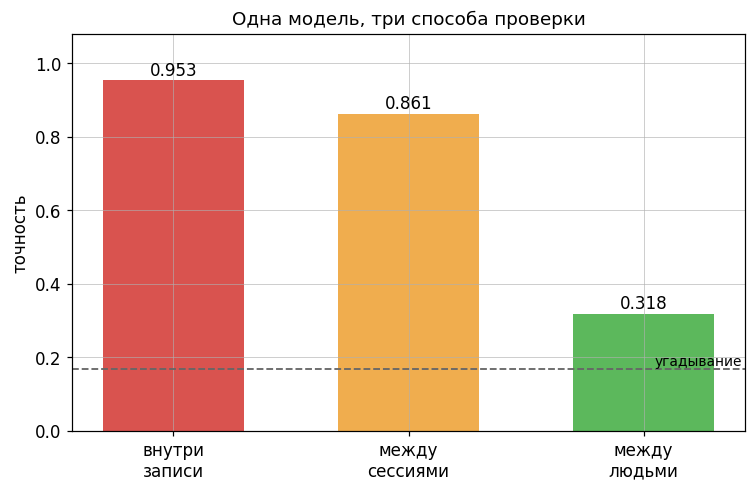

In [9]:
names = ["внутри\nзаписи", "между\nсессиями", "между\nлюдьми"]
values = [within, cross_session, cross_subject]
colors = ["#d9534f", "#f0ad4e", "#5cb85c"]

fig, ax = plt.subplots(figsize=(7.0, 4.6))
bars = ax.bar(names, values, color=colors, width=0.6)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.015, "%.3f" % value,
            ha="center", fontsize=11)
ax.axhline(1.0 / len(GESTURES), color="#666", ls="--", lw=1.2)
ax.text(2.42, 1.0 / len(GESTURES) + 0.012, "угадывание", ha="right", fontsize=9)
ax.set(ylim=(0, 1.08), ylabel="точность",
       title="Одна модель, три способа проверки")
fig.tight_layout()
plt.show()

Красный столбик — то число, которое хочется написать в отчёте. Зелёный — то,
что получится, когда браслет наденет другой человек. В лабе E10 мы увидим,
что и это ещё не предел честности: там модель работает в потоке.

## Задания

1. Приведи все три точности для своего варианта и объясни каждое падение:
   что именно меняется между обучением и проверкой в каждом случае.
2. Сделай проверку «между людьми» для трёх разных пар испытуемых
   (`list_subjects()` покажет доступные номера). Насколько разброс велик и
   можно ли по одной паре судить о модели?
3. Поставь `STEP_MS = 200.0` (окна перестают перекрываться) и повтори способ
   1. Насколько сократился разрыв с честной проверкой?